LAB REPORT

TITLE:
Generation of Random Numbers Using Pseudo Random Number Generator and Testing Randomness Using Chi-Square Test

Objective
The objectives of this experiment are:

To understand the concept of random and pseudo-random numbers.

To generate random numbers using a pseudo-random number generation technique.

To study the working principle of Linear Congruential Generator (LCG).

To analyze the uniformity of generated random numbers.

To perform the Chi-Square Goodness-of-Fit Test on generated random numbers.

To determine whether the generated numbers follow a uniform distribution.

To understand the importance of randomness testing in simulations and statistical applications.


Theory
2.1 Introduction to Random Numbers

A number is a number that we pick from a set of numbers and each number has the same chance of being picked.

We use numbers in a lot of things like:

Computer simulations

Cryptography

sampling

Gaming applications

Monte Carlo methods

Artificial Intelligence

Network security

A good set of random numbers should have some important characteristics. Random numbers should have:

Uniformity, which means every number should come up often.

Independence, which means that if one number comes up it does not affect the number.

Unpredictability, which means we cannot guess what the next number will be based on the numbers that came before.


2.2 Pseudo Random Numbers

Computers cannot make random numbers because they do what they are told to do.

Instead computers make Pseudo Random Numbers.

A pseudo random number is a number that a computer generates using a math formula. It looks like it is random but it is not really. If we give the computer the starting point it will always make the same sequence of numbers.

The good things about pseudo numbers are:

They are made quickly

They are easy to make

We can get the results again if we want to

They are good for simulations

The bad things, about pseudo numbers are:

The bad things, about pseudo numbers are:

They are not really random

The sequence of numbers will eventually start again

If someone knows the formula and the starting point they can guess what the numbers will be.


2.3 Linear Congruential Generator

The Linear Congruential Generator is a simple way to generate random numbers. It is used a lot.

The formula, for the Linear Congruential Generator is:

To use the Linear Congruential Generator we do these steps:

We pick a seed, which's the starting number.

We pick a multiplier, which's the special number that we multiply by.

We pick an increment, which's the number that we add.

We pick a modulus, which's the modulus.

Then we use the Linear Congruential Generator formula over and over again to get a list of numbers.

The Linear Congruential Generator will give us a sequence of Linear Congruential Generator numbers.

2.4 Randomness Testing

We need to check if the numbers we get are really random after we make them.

The numbers have to act like they're truly random.

To do this we use some tests.

Some common tests are:

Chi-Square Test

Kolmogorov-Smirnov Test

Runs Test

Poker Test

Gap Test

In this experiment we use the Chi-Square Test to see if our random numbers are really random.

The Chi-Square Test is what we have chosen for this experiment.

2.5 Chi-Square Test

The Chi-Square Goodness-of-Fit Test is used to find out if the frequencies we see are really different, from what we expect to see.

The Chi-Square Goodness-of-Fit Test checks if the random numbers we get are spread out evenly.

Alternative Hypothesis

Null Hypothesis (H₀)

The Chi-Square Test assumes that the random numbers we generate are spread out evenly this is what we call a distribution.

Alternative Hypothesis (H₁)

The Alternative Hypothesis of the Chi-Square Test says that the random numbers we generate do not follow a distribution.

Chi-Square Formula

The chi-square (χ2) statistic is commonly calculated as:
χ2=∑(O−E)2​/E



Algorithm
For Pseudo Random Number Generation:

Start.
Select seed value X₀.
Select a, c, and m.
Apply LCG formula.
Generate required random numbers.
Store generated numbers.
Stop.


For Chi-Square Test:
Divide the interval into equal classes.
Count observed frequency in each class.
Calculate expected frequency.
Compute χ² statistic.
Determine degrees of freedom.
Find critical value from table.
Compare values.
Draw conclusion.
Seed & Random State in Python

Key Concepts: Seed — A starting valuethat initializes the random number generator. Same seed → same sequence of "random" numbers every time.
Random State — The internal state of the generator at any point. It determines what the next number will be.

Think of it like a recipe: the seed is the starting ingredient, and the random state is where you are in the recipe steps.

In [2]:
import random
import numpy as np
# ─────────────────────────────────────────
# 1. WITHOUT a seed — different every run
# ─────────────────────────────────────────
print("=== No Seed ===")
print(random.randint(1, 100))   # e.g. 42
print(random.randint(1, 100))   # e.g. 87  (changes each run)



=== No Seed ===
60
68


In [3]:
# ─────────────────────────────────────────
# 2. WITH a seed — reproducible results
# ─────────────────────────────────────────
print("\n=== With Seed (42) ===")
random.seed(42)
print(random.randint(1, 100))   # Always: 82
print(random.randint(1, 100))   # Always: 15



=== With Seed (42) ===
82
15


In [4]:
# Same seed again → same sequence restarts
random.seed(42)
print(random.randint(1, 100))   # Always: 82  ← same as before!


82


In [5]:
# ─────────────────────────────────────────
# 3. Different seeds → different sequences
# ─────────────────────────────────────────
print("\n=== Different Seeds ===")
random.seed(1)
print([random.randint(1, 10) for _ in range(5)])   # [3, 10, 2, 5, 2]

random.seed(99)
print([random.randint(1, 10) for _ in range(5)])   # [1, 6, 4, 10, 7]



=== Different Seeds ===
[3, 10, 2, 5, 2]
[7, 7, 4, 10, 3]


In [7]:
# ─────────────────────────────────────────
# 4. Saving & Restoring Random State
# ─────────────────────────────────────────
print("\n=== Save & Restore State ===")
random.seed(42)
print(random.randint(1, 100))   # 82

state = random.getstate()       # 📸 Snapshot of current state

print(random.randint(1, 100))   # 15
print(random.randint(1, 100))   # 4

random.setstate(state)          # ⏪ Restore to snapshot
print(random.randint(1, 100))   # 15 again! (replays from snapshot)



=== Save & Restore State ===
82
15
4
15


In [8]:
# ─────────────────────────────────────────
# 5. NumPy seed (for arrays / ML)
# ─────────────────────────────────────────
print("\n=== NumPy Seed ===")
np.random.seed(42)
print(np.random.randint(1, 100, size=5))   # Always: [52 93 15 72 61]

# Modern NumPy (recommended)
rng = np.random.default_rng(seed=42)
print(rng.integers(1, 100, size=5))        # Always: [52 99 14 34 60]



=== NumPy Seed ===
[52 93 15 72 61]
[ 9 77 65 44 43]


In [9]:
# ─────────────────────────────────────────
# 6. Real-world use case: Train/Test Split
# ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

data = list(range(100))

# Without seed → different split every run ❌
X_train, X_test = train_test_split(data, test_size=0.2)

# With seed → same split every run ✅
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train[:5]}, Test: {X_test[:5]}")


Train: [55, 88, 26, 42, 69], Test: [83, 53, 70, 45, 44]


Cryptography (Security Systems)
Random numbers are the backbone of digital security.

Where it is used:
Password generation
Encryption keys (RSA, AES)
Secure communication (HTTPS, SSL/TLS)
OTP (One-Time Passwords)

Why randomness matters:

If keys are predictable, hackers can easily break the system.

Example: A secure app generates a random encryption key using a seed-based PRNG or hardware RNG. Even a small pattern can lead to security breaches.

Simulation (Modeling Real Systems)
Random numbers are used to simulate real-life systems that are complex or expensive to test.

Applications:
Chemical reaction simulation
Traffic flow simulation
Weather forecasting models
Queueing systems (banks, hospitals)
Game physics (loot drops, AI behavior)
Example:

In your chemical reaction simulation:
random numbers determine reaction events helps model molecular behavior realistically

Machine Learning (AI & Data Science)
Randomness is essential in training AI models.

Where it is used:
Train-test split
Weight initialization in neural networks
Shuffling datasets
Random forests (decision trees)
Dropout layers in deep learning

Why it matters:

Without randomness:

Models may overfit
Training becomes biased
Results are not generalizable

Scientific Studies & Research
Random numbers are used in experiments and statistical analysis.

Applications:
Sampling populations in surveys
Clinical trials (medicine testing)
Monte Carlo simulations
Hypothesis testing (Chi-square, t-test)
Physics simulations (particle movement)

Example: In drug testing:
patients are randomly assigned to control and test groups ensures unbiased results

Generation of Random Numbers

Random numbers are values generated in such a way that they appear unpredictable. Since computers are deterministic, they use Pseudo Random Number Generators (PRNGs) to generate sequences that mimic randomness.

inear Congruential Generator (LCG)
Definition:
The Linear Congruential Generator is one of the simplest and oldest PRNG methods.

⚙️ Features
Very fast
Easy to implement
Low memory usage

❌ Limitations
Poor randomness quality
Short period if parameters are bad
Not suitable for cryptography

In [10]:
# LCG Python code without seed keyword
# LCG - Linear Congruential Generator
# Formula: X(n+1) = (a * Xn + c) % m

def lcg(start_value, a, c, m, count):
    """
    Linear Congruential Generator

    Parameters:
    -----------
    start_value : int  -> Initial X0 value (0 <= start_value < m)
    a           : int  -> Multiplier     (0 < a < m)
    c           : int  -> Increment      (0 <= c < m)
    m           : int  -> Modulus        (m > 0)
    count       : int  -> How many numbers to generate
    """

    results = []
    X = start_value             # X0 = starting point

    for i in range(count):
        X = (a * X + c) % m     # Core LCG formula
        results.append(X)

    return results


# ── Parameters ───────────────────────────────
# ── Parameters ───────────────────────────────
start_value = 7    # X0: starting value
a           = 5    # multiplier
c           = 3    # increment
m           = 16   # modulus
count       = 8    # number of values to generate # multiplier
# ─────────────────────────────────────────────

random_numbers = lcg(start_value, a, c, m, count)
normalized     = [round(x / m, 4) for x in random_numbers]

# ── Print Results ─────────────────────────────
print(f"Start Value (X0) : {start_value}")
print(f"Parameters       : a={a}, c={c}, m={m}")
print()
print(f"{'Step':<6} {'Xn+1':<8} {'Normalized'}")
print("-" * 28)
for i, (val, norm) in enumerate(zip(random_numbers, normalized)):
    print(f"{i:<6} {val:<8} {norm}")

Start Value (X0) : 7
Parameters       : a=5, c=3, m=16

Step   Xn+1     Normalized
----------------------------
0      6        0.375
1      1        0.0625
2      8        0.5
3      11       0.6875
4      10       0.625
5      5        0.3125
6      12       0.75
7      15       0.9375


In [11]:
# Linear Congruential Generator (LCG)

def lcg(seed, a, c, m, n):
    numbers = []
    x = seed
    
    for i in range(n):
        x = (a * x + c) % m
        numbers.append(x)
    
    return numbers


# Example usage
seed = 5
a = 3
c = 7
m = 16
n = 10

result = lcg(seed, a, c, m, n)
print("LCG Output:", result)

LCG Output: [6, 9, 2, 13, 14, 1, 10, 5, 6, 9]


Mersenne Twister
🔢 Definition
The Mersenne Twister is a highly advanced PRNG used in many programming languages (like Python).

⭐ Features
Very high-quality randomness
Extremely large period
Fast generation
Used in Python random module

❌ Limitations
Not cryptographically secure
Predictable if internal state is known

In [12]:
import random

# Seed for reproducibility
random.seed(42)

# Generate random numbers
numbers = [random.random() for _ in range(10)]

print("Mersenne Twister Output:", numbers)

Mersenne Twister Output: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124, 0.6766994874229113, 0.8921795677048454, 0.08693883262941615, 0.4219218196852704, 0.029797219438070344]


XOR Shift Generator 🔢 Definition
An XOR shift generator produces random numbers using bitwise XOR and shift operations.

⭐ Features
Very fast (CPU efficient)
Simple implementation
Good for simulations

❌ Limitations
Weak statistical quality compared to Mersenne Twister
Not secure for cryptography

In [13]:
# XOR Shift Generator

def xorshift(seed, n):
    x = seed
    result = []
    
    for _ in range(n):
        x ^= (x << 13) & 0xFFFFFFFF
        x ^= (x >> 17)
        x ^= (x << 5) & 0xFFFFFFFF
        
        result.append(x & 0xFFFFFFFF)
    
    return result


# Example usage
seed = 123456789
n = 10

print("XOR Shift Output:", xorshift(seed, n))

XOR Shift Output: [2714967881, 2238813396, 1250077441, 3820100336, 3177519686, 3684138832, 3151087790, 3662508108, 4242376622, 3374601978]


Cryptographically Secure Pseudo Random Number Generator (CSPRNG)
🔐 Definition
A CSPRNG is a special type of PRNG designed to be secure against prediction.

⭐ Features
Highly secure
Unpredictable output
Suitable for sensitive systems

🔐 Algorithms Used
AES-based generators
SHA-based DRBG (Deterministic Random Bit Generator)
OS-based generators (Linux /dev/urandom)

In [14]:
import secrets

# Generate secure random numbers
numbers = [secrets.randbelow(100) for _ in range(10)]

print("CSPRNG Output:", numbers)

CSPRNG Output: [66, 48, 96, 61, 92, 96, 57, 93, 2, 70]


Values of r: [ 17  18  47 120 189 142  59 212  41 202   7 240  85 198 147 204  65 130
 223 104 237 254 235 196  89  58 183 224 133  54  67 188 113 242 143  88
  29 110 155 180 137 170 103 208 181 166 243 172 161  98  63  72  77 222
  75 164 185  26  23 192 229  22 163 156 209 210 239  56 125  78 251 148
 233 138 199 176  21 134  83 140   1  66 159  40 173 190 171 132  25 250
 119 160  69 246   3 124  49 178  79  24 221  46  91 116  73 106  39 144
 117 102 179 108  97  34 255   8  13 158  11 100 121 218 215 128 165 214
  99  92 145 146 175 248  61  14 187  84 169  74 135 112 213  70  19  76
 193   2  95 232 109 126 107  68 217 186  55  96   5 182 195  60 241 114
  15 216 157 238  27  52   9  42 231  80  53  38 115  44  33 226 191 200
 205  94 203  36  57 154 151  64 101 150  35  28  81  82 111 184 253 206
 123  20 105  10  71  48 149   6 211  12 129 194  31 168  45  62  43   4
 153 122 247  32 197 118 131 252 177  50 207 152  93 174 219 244 201 234
 167  16 245 230  51 236 225 162 127 1

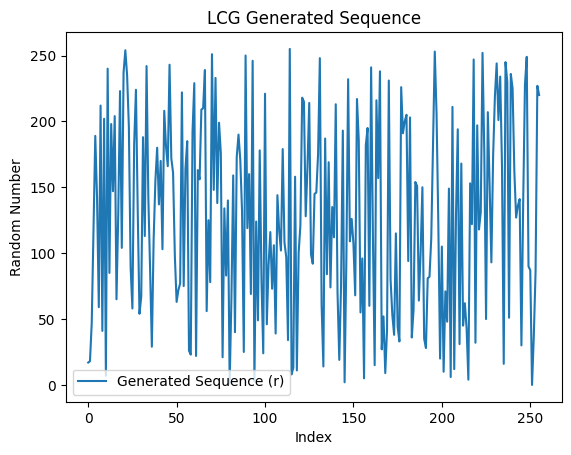

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
       import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
       import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
# Constants
iterator = 256 # Number of random numbers to generate
a = 29 # Multiplier
b = 37 # Increment
p = 256 # Modulus
n = 8 # Number of bins for Chi-Square test
x02 = 0 # Chi-Square statistic initialization
critical_value = chi2.pdf(1 - 0.05, df = n - 1) # Chi-Square critical value
# Initialize arrays
r = np.ones(shape=(iterator), dtype=int) # Array to store generated random numbers
ei = iterator / n # Expected frequency for each bin
c = np.zeros(shape=(n), dtype=int) # Bin counts
# Initial seed
r[0] = 17
# Generate random numbers using LCG
for i in range(0, iterator - 1):
 r[i + 1] = (r[i] * a + b) % p
# Bin the generated numbers and compute frequencies
for i in range(iterator):
    if r[i] <= 31:
        c[0] += 1
    elif r[i] <= 63:
       c[1] += 1
    elif r[i] <= 95:
        c[2] += 1
    elif r[i] <= 127:
        c[3] += 1
    elif r[i] <= 159:
        c[4] += 1
    elif r[i] <= 191:
        c[5] += 1
    elif r[i] <= 223:
        c[6] += 1
    elif r[i] <= 255:
        c[7] += 1
 # Compute Chi-Square statistic
for i in range(n):
 x02 += ((c[i] - ei) ** 2) / ei
# Print results
print("Values of r:", r)
print("Values of c (bin frequencies):", c)
print("Value of Chi-Square statistic (x02):", x02)
print("The critical value is", critical_value)
print("Chi square test passed" if x02 <= critical_value else "Chi squsre test failed")
# Visualize the generated random numbers
plt.figure()
plt.plot(r, label="Generated Sequence (r)")
plt.xlabel("Index")
plt.ylabel("Random Number")
plt.title("LCG Generated Sequence")
plt.legend()
plt.show()       

Result
The pseudo-random numbers were successfully generated using the Linear Congruential Generator method. The Chi-Square Goodness-of-Fit Test was applied to evaluate the uniformity of the generated sequence. Since the calculated Chi-Square value was less than the critical Chi-Square value, the generated random numbers were found to follow a uniform distribution and passed the randomness test.

Conclusion
This experiment demonstrated the generation of pseudo-random numbers using a mathematical algorithm. The Linear Congruential Generator produced a sequence of numbers that appeared random. The Chi-Square Test was used to verify the uniformity of the generated numbers. The test results indicated that the generated sequence satisfied the requirements of a uniform random distribution. Therefore, the pseudo-random number generator was considered suitable for simulation and statistical applications.

Discussion
In this experiment, pseudo-random numbers were generated using the Linear Congruential Generator (LCG) method and tested for uniformity using the Chi-Square Test. The observed frequencies were compared with the expected frequencies, and the calculated Chi-Square value was less than the critical value. This indicates that the generated numbers are uniformly distributed and exhibit satisfactory randomness. Therefore, the pseudo-random number generator is suitable for simulation and statistical applications.